# Notebook 01: Data Exploration & Quality Audit

In [1]:
import sys
import os
sys.path.append(os.path.abspath(os.path.join('..')))

In [2]:
import duckdb
import yaml
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import re

In [3]:
DB_PATH = "../data/warehouse.duckdb"

In [4]:
with duckdb.connect(DB_PATH) as con:
    tables = con.execute("""
        SELECT table_name
        FROM information_schema.tables
        WHERE table_schema = 'bronze';
    """).df().table_name.values

In [5]:
print(tables)

['job_postings_raw' 'sc_census_income_raw' 'sc_census_labour_raw'
 'sc_graduates_trends_raw' 'sc_labour_trends_raw' 'sc_wages_trends_raw']


## 1. Data Integrity & Schema Audit

### Schema Check

In [6]:
for t_name in tables:
    with duckdb.connect(DB_PATH) as con:
        print(f"--- Profiling Schema: {t_name} ---\n")
        print(con.execute(f"""
            SELECT 
                CASE WHEN LENGTH(column_name) > 28
                    THEN SUBSTR(column_name, 1, 25) || '...'
                    ELSE column_name
                END AS column_name,
                data_type
            FROM information_schema.columns
            WHERE table_name = '{t_name}'
            AND table_schema = 'bronze';
        """).df())
        print()

--- Profiling Schema: job_postings_raw ---

     column_name  data_type
0       job_hash    VARCHAR
1      adzuna_id    VARCHAR
2          title    VARCHAR
3        company    VARCHAR
4     created_at  TIMESTAMP
5       category    VARCHAR
6       location    VARCHAR
7    description    VARCHAR
8    search_term    VARCHAR
9    ingested_at  TIMESTAMP
10        source    VARCHAR
11  redirect_url    VARCHAR

--- Profiling Schema: sc_census_income_raw ---

                     column_name  data_type
0                      Geography    VARCHAR
1                     Gender (3)    VARCHAR
2                        Age (4)    VARCHAR
3   Highest certificate, dipl...    VARCHAR
4   Major field of study - Cl...    VARCHAR
5   Work activity during the ...    VARCHAR
6   Occupation - Unit group -...    VARCHAR
7   Employment income statist...    VARCHAR
8                       REF_DATE    VARCHAR
9                          VALUE     DOUBLE
10                           pid    VARCHAR
11             

### Null-Value Profiling

In [7]:
def count_nulls(tables):
    counts = None
    with duckdb.connect(DB_PATH) as con:
        for t_name in tables:
            target_col = "VALUE" if t_name.startswith("sc_") else "description"
            df = con.execute(f"""
                SELECT
                    '{t_name}' AS table_name,
                    COUNT(*) AS total_rows,
                    SUM(CASE WHEN "{target_col}" IS NULL THEN 1 ELSE 0 END) AS nulls_count,
                    ROUND(100.0 * SUM(CASE WHEN "{target_col}" IS NULL THEN 1 ELSE 0 END) / COUNT(*), 2) AS null_pct
                FROM bronze.{t_name};
            """).df()
            counts = pd.concat([counts, df])
        print(counts)

In [8]:
count_nulls(tables)

                table_name  total_rows  nulls_count  null_pct
0         job_postings_raw        3453          0.0      0.00
0     sc_census_income_raw          44          2.0      4.55
0     sc_census_labour_raw         129          0.0      0.00
0  sc_graduates_trends_raw          84          0.0      0.00
0     sc_labour_trends_raw          48          0.0      0.00
0      sc_wages_trends_raw          16          0.0      0.00


### Job Description Truncation Audit

In [9]:
with duckdb.connect(DB_PATH) as con:
    print(con.execute(f"""
        SELECT
            MIN(LENGTH(description)) AS min_text_len,
            AVG(LENGTH(description)) AS avg_text_len,
            MAX(LENGTH(description)) AS max_text_len,
            STDDEV_SAMP(LENGTH(description)) AS std
        FROM bronze.job_postings_raw;
    """).df().round(2))

   min_text_len  avg_text_len  max_text_len      std
0           500       5538.28         19112  2616.92


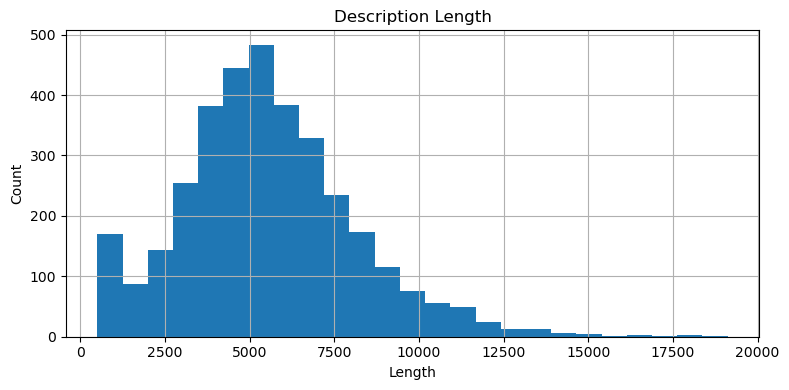

In [10]:
with duckdb.connect(DB_PATH) as con:
    con.execute(f"""
        SELECT LENGTH(description) as text_length
        FROM bronze.job_postings_raw;
    """).df().round(2).hist(bins=25, figsize=(8,4))
    plt.title("Description Length")
    plt.xlabel("Length")
    plt.ylabel("Count")
    plt.tight_layout()

## 2. Labor Market Distribution

In [11]:
with duckdb.connect(DB_PATH) as con:
    posting_counts = con.execute("""
        SELECT
            search_term,
            COUNT(*) AS num_postings,
            ROUND(COUNT(*) * 100.0 / SUM(COUNT(*)) OVER(), 5) AS pct_postings
        FROM bronze.job_postings_raw
        GROUP BY search_term
        ORDER BY num_postings DESC;
    """).df()

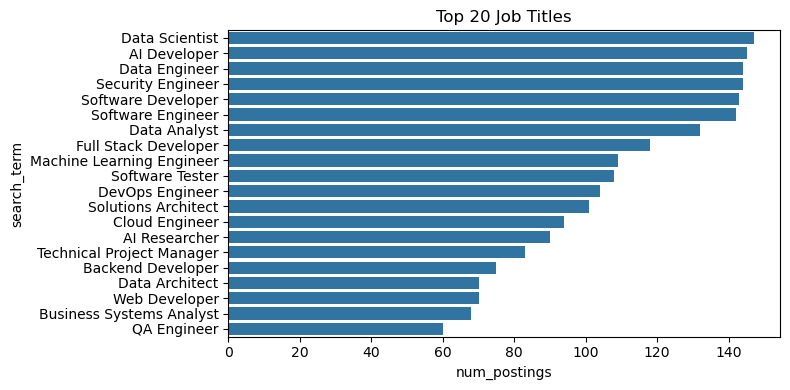

In [12]:
plt.figure(figsize=(8,4))
sns.barplot(
    posting_counts.head(20), 
    x="num_postings", y="search_term"
)
plt.title("Top 20 Job Titles")
plt.tight_layout()
plt.show()

In [13]:
posting_counts.head(20)

,search_term,num_postings,pct_postings
0,Data Scientist,147,4.25717
1,AI Developer,145,4.19925
2,Data Engineer,144,4.17029
3,Security Engineer,144,4.17029
4,Software Developer,143,4.14133
5,Software Engineer,142,4.11237
6,Data Analyst,132,3.82276
7,Full Stack Developer,118,3.41732
8,Machine Learning Engineer,109,3.15668
9,Software Tester,108,3.12772


## 3. Data Preprocessing Prototyping

### NOC Alignment & Taxonomy Consolidation

The [2021 National Occupational Classification (NOC)](https://noc.esdc.gc.ca/Structure/Hierarchy) provides a granular breakdown of technical roles. To optimize our SkillPath-Engine, we would map our scraped titles to the following core units:
- **21210 (Math & Stats):** Develops and applies mathematical or statistical techniques to solve complex problems and assess financial risk.
- **21211 (Data Science):** Uses advanced analytics, machine learning, and predictive modeling to extract insights from unstructured data.
- **21220 (Cybersecurity):** Plans and implements security measures to protect networks, devices, and organizational information.
- **21221 (Business Systems):** Translates corporate strategic objectives into technical IT architectures and tasks.
- **21222 (Information Systems):** Analyzes and assesses system requirements while implementing information development plans and policies.
- **21223 (Database & Data Admin):** Designs, develops, and administers data management solutions and administration standards.
- **21230 (Systems Programming):** Writes and tests code for software applications, operating systems, and communications software.
- **21231 (Software Engineering):** Researches and designs technical environments, embedded software, and information warehouses.
- **21232 (Software Development):** Designs and writes code for new systems to ensure overall efficiency and effectiveness.
- **21233 (Web Design):** Develops the visual layout, presentation, and user-interface functionality of websites.
- **21234 (Web Development):** Uses programming languages to create, modify, and integrate website capacity and performance.

### StatCan Table Transformations

In [14]:
from src.transformation.statcan_silver_factory import (
    build_silver_graduates,
    build_silver_wage_trends,
    build_silver_census_income,
    build_silver_labour_force_trends,
    build_silver_census_employment
)

#### Graduates

In [15]:
graduates = build_silver_graduates()
graduates.head(3)

,education_level,field_of_study,date,graduates,ingested_at,source,noc_code,noc-5,noc-3
0,Bachelor's degree,Computer science,2010-01-01,2484.0,2026-02-28 13:28:23.277056,StatCan,2122,None,212
1,Bachelor's degree,Computer science,2011-01-01,2562.0,2026-02-28 13:28:23.277056,StatCan,2122,None,212
2,Bachelor's degree,Computer science,2012-01-01,2568.0,2026-02-28 13:28:23.277056,StatCan,2122,None,212


In [16]:
graduates["field_of_study"].value_counts()

field_of_study
Computer science              42
Mathematics and statistics    42
Name: count, dtype: int64

#### Employment Income

In [17]:
census_income = build_silver_census_income()
census_income.head(3)

,education_level,occupation,median_income,ingested_at,source,noc_code,noc-5,noc-3
0,Bachelor's degree,Professional occupations in applied sciences (...,86000.0,2026-02-28 13:30:09.539685,StatCan,212,None,212
1,Bachelor's degree,Data scientists,87000.0,2026-02-28 13:30:09.539685,StatCan,21211,21211,212
2,Bachelor's degree,Cybersecurity specialists,92000.0,2026-02-28 13:30:09.539685,StatCan,21220,21220,212


In [18]:
census_income["noc_code"].unique()

array(['212', '21211', '21220', '21221', '21222', '21223', '21230',
       '21231', '21232', '21233', '21234'], dtype=object)

In [19]:
income_trends = build_silver_wage_trends()
income_trends.head(3)

,occupation,date,weekly_wages,ingested_at,source,noc_code,noc-5,noc-3,median_income
0,Professional occupations in applied sciences (...,2010-01-01,1250.0,2026-03-04 01:11:05.187950,StatCan,212,None,212,65000.0
1,Professional occupations in applied sciences (...,2011-01-01,1317.2,2026-03-04 01:11:05.187950,StatCan,212,None,212,68494.4
2,Professional occupations in applied sciences (...,2012-01-01,1346.0,2026-03-04 01:11:05.187950,StatCan,212,None,212,69992.0


#### Labour Force Status

In [20]:
census_labour = build_silver_census_employment()
census_labour.head(3)

,education_level,occupation,ingested_at,source,employed,unemployed,noc_code,noc-5,noc-3,labour_force,unemployment_rate
0,Bachelor's degree,Professional occupations in applied sciences (...,2026-02-28 13:30:18.356680,StatCan,242470.0,7955.0,212,None,212,250425.0,3.18
1,Bachelor's degree,Data scientists,2026-02-28 13:30:18.356680,StatCan,4565.0,190.0,21211,21211,212,4755.0,4.00
2,Bachelor's degree,Cybersecurity specialists,2026-02-28 13:30:18.356680,StatCan,5050.0,100.0,21220,21220,212,5150.0,1.94


In [21]:
census_labour["noc_code"].unique()

array(['212', '21211', '21220', '21221', '21222', '21223', '21230',
       '21231', '21232', '21233', '21234'], dtype=object)

In [22]:
labour_trends = build_silver_labour_force_trends()
labour_trends.head(3)

,occupation,date,ingested_at,source,labour force,proportion of employment,unemployment rate,noc_code,noc-5,noc-3
0,Professional occupations in applied sciences (...,2010-01-01,2026-02-28 13:28:18.222207,StatCan,437.9,100.0,3.1,212,None,212
1,Professional occupations in applied sciences (...,2011-01-01,2026-02-28 13:28:18.222207,StatCan,428.1,100.0,2.7,212,None,212
2,Professional occupations in applied sciences (...,2012-01-01,2026-02-28 13:28:18.222207,StatCan,452.2,100.0,2.9,212,None,212


### Job Titles Mapping

In [23]:
from src.transformation.role_mapper import map_roles
from scipy.interpolate import make_interp_spline, UnivariateSpline

In [24]:
with duckdb.connect(DB_PATH) as con:
    job_headers = con.execute("""
        SELECT search_term, title
        FROM bronze.job_postings_raw;
    """).df()

In [25]:
audited_noc = map_roles(job_headers, yaml_path="../config/role_mapping.yaml", full_report=True)

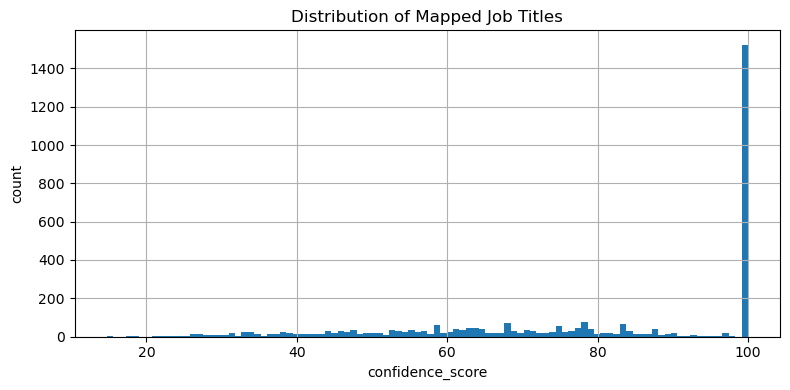

In [26]:
audited_noc["confidence_score"].hist(bins=100, figsize=(8,4))
plt.title("Distribution of Mapped Job Titles")
plt.xlabel("confidence_score")
plt.ylabel("count")
plt.tight_layout()

In [27]:
with pd.option_context('display.max_rows', None, 'display.max_columns', None, 'display.max_colwidth', None):
    print(audited_noc["confidence_score"].round(0).value_counts().sort_index())

confidence_score
15.0        1
18.0        1
19.0        3
21.0        3
22.0        5
23.0        4
24.0        4
25.0        3
26.0       13
27.0       15
28.0        9
29.0       11
30.0       11
31.0        9
32.0       15
33.0       22
34.0       24
35.0       17
36.0       10
37.0       14
38.0       22
39.0       21
40.0       16
41.0       22
42.0       11
43.0       16
44.0       27
45.0       21
46.0       32
47.0       43
48.0       20
49.0       20
50.0       24
51.0       20
52.0       18
53.0       38
54.0       29
55.0       40
56.0       30
57.0       34
58.0       18
59.0       61
60.0       30
61.0       45
62.0       45
63.0       49
64.0       49
65.0       44
66.0       23
67.0       23
68.0       78
69.0       32
70.0       28
71.0       43
72.0       27
73.0       21
74.0       28
75.0       58
76.0       30
77.0       53
78.0       86
79.0       46
80.0       18
81.0       16
82.0       21
83.0       52
84.0       48
85.0       17
86.0       14
87.0       24
88.

In [28]:
thresholds = np.arange(0, 101, 1)
percentages = []

for t in thresholds:
    mask = audited_noc['confidence_score'] >= t
    pct = 100 * len(audited_noc[mask]) / len(audited_noc)
    percentages.append(pct)

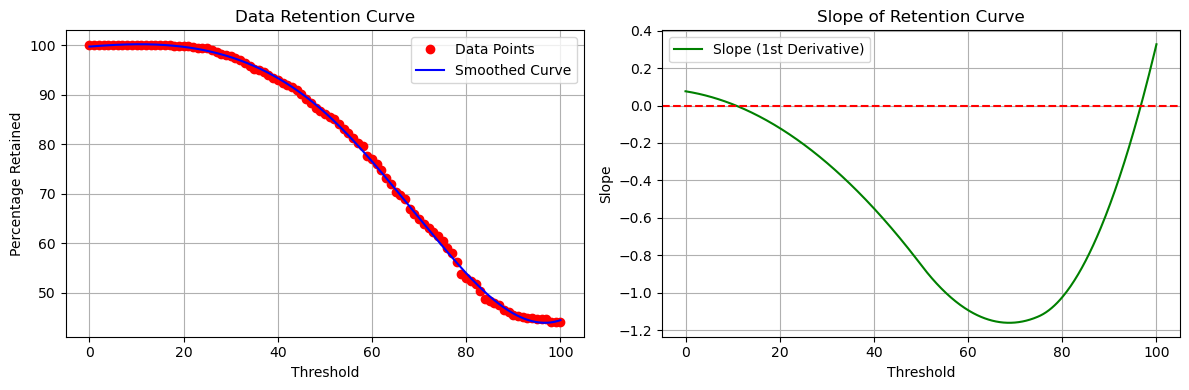

In [29]:
spline = UnivariateSpline(thresholds, percentages, s=20)
x_smooth = np.linspace(thresholds.min(), thresholds.max(), 500)
y_smooth = spline(x_smooth)
y_der = spline.derivative()(x_smooth)

# Plotting to verify
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(thresholds, percentages, 'ro', label='Data Points')
plt.plot(x_smooth, y_smooth, 'b-', label='Smoothed Curve')
plt.title('Data Retention Curve')
plt.xlabel('Threshold')
plt.ylabel('Percentage Retained')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(x_smooth, y_der, 'g-', label='Slope (1st Derivative)')
plt.axhline(y=0, color='r', linestyle='--')
plt.title('Slope of Retention Curve')
plt.xlabel('Threshold')
plt.ylabel('Slope')
plt.legend()
plt.grid(True)

plt.tight_layout()

In [30]:
steepest_idx = np.argmin(y_der)
steepest_threshold = x_smooth[steepest_idx]
print(f"The Steepest Point (cliff): {steepest_threshold:.2f}")

The Steepest Point (cliff): 68.74


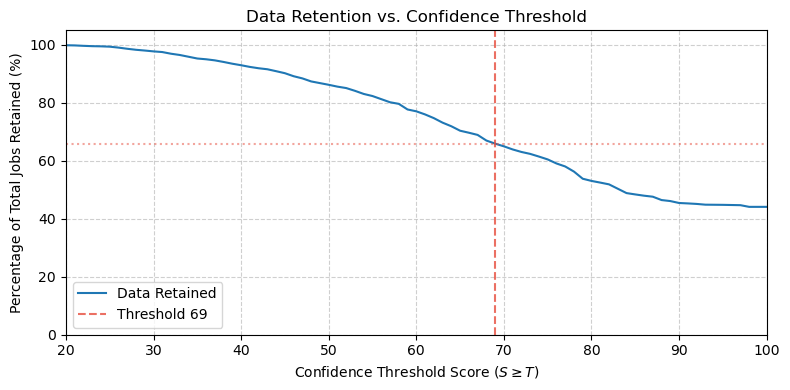

In [31]:
plt.figure(figsize=(8, 4))
plt.plot(thresholds, percentages, label='Data Retained')

# Highlight the "Recommended Threshold"
RECOMMENDED_T = int(np.round(steepest_threshold, 0))
retention_at_T = percentages[RECOMMENDED_T]

plt.axvline(x=RECOMMENDED_T, color='#e74c3c', linestyle='--', alpha=0.8, label=f'Threshold {RECOMMENDED_T}')
plt.axhline(y=retention_at_T, color='#e74c3c', linestyle=':', alpha=0.5)

plt.title("Data Retention vs. Confidence Threshold")
plt.xlabel("Confidence Threshold Score ($S \geq T$)")
plt.ylabel("Percentage of Total Jobs Retained (%)")

plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(loc='lower left')
plt.ylim(0, 105)
plt.xlim(20, 100)

plt.tight_layout()
plt.show()

In [32]:
print(f"~%{percentages[69]:.1f} of data is retained with a threshold of {steepest_threshold:.2f}")

~%65.9 of data is retained with a threshold of 68.74


In [33]:
audited_noc[audited_noc["confidence_score"].between(steepest_threshold, np.ceil(steepest_threshold))].sample(frac=1.0).head(15)

,search_term,title,clean_title,matched_label,confidence_score,assigned_noc,match_method
3325,Engineering Manager,IAM Engineer – Authentication Management (AM),iam engineer - authentication management am,Engineering Manager,68.75,20012,Semantic
2868,DevOps Engineer,SQL Database Developer/Data Modelling,sql database developer/data modelling,Database Engineer,68.79,21223,Semantic
1346,Security Engineer,Senior IAM Systems Engineer (Global Security),iam systems engineer global security,Security Engineer,68.96,21220,Semantic
2317,Solutions Architect,Architecte de solutions Azure/Azure Solution A...,architecte cloud/cloud architect,Cloud Engineer,68.78,21231,Semantic
1757,AI Developer,AI Product Engineer | Ingénieur produit IA,ai product engineer ingenieur produit ia,AI Developer,68.92,21211,Semantic
2248,Technical Architect,Senior Android Developer,android developer,Java Developer,68.78,21232,Semantic
1286,C# Developer,.NET Cloud Developer,net cloud developer,Cloud Engineer,68.90,21231,Semantic
1681,Data Scientist,Director of Data & Analytics Engineering,director data analytics engineer,Data Analytics Specialist,68.78,21223,Semantic


With a threshold of 68.54, the mapping of job titles is quite effective.